# SpaceX Falcon 9 First Stage Landing Prediction
## Machine Learning Pipeline

**Objective:** Predict whether a Falcon 9 first-stage booster will land successfully using historical mission data.

SpaceX advertises Falcon 9 launches at ~$62M vs competitors at $165M+. The cost savings come from reusing the first stage. Accurately predicting landing success enables better resource allocation and launch cost estimation.

**Models compared:** Logistic Regression, SVM, Decision Tree, KNN, LightGBM, XGBoost  
**Advanced analysis:** SHAP feature importance for model explainability

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import lightgbm as lgb
import xgboost as xgb
import shap

print('All libraries loaded successfully.')

Matplotlib is building the font cache; this may take a moment.


All libraries loaded successfully.


## 2. Load Data

In [2]:
data = pd.read_csv('../data/dataset_part_2.csv')
X    = pd.read_csv('../data/dataset_part_3.csv')

print('dataset_part_2 shape:', data.shape)
print('dataset_part_3 shape:', X.shape)
data.head()

dataset_part_2 shape: (90, 18)
dataset_part_3 shape: (90, 83)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [3]:
X.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


## 3. Prepare Features and Target

In [4]:
# Target variable: 1 = successful landing, 0 = failed landing
Y = data['Class'].to_numpy()

print('Class distribution:')
print(pd.Series(Y).value_counts())
print(f'\nLanding success rate: {Y.mean():.1%}')

Class distribution:
1    60
0    30
Name: count, dtype: int64

Landing success rate: 66.7%


In [5]:
# Store feature names before scaling (needed for SHAP later)
feature_names = X.columns.tolist()

# Standardize features
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=2
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 72
Test samples     : 18
Features         : 83


## 4. Helper Functions

In [6]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    ax.xaxis.set_ticklabels(['Did Not Land', 'Landed'])
    ax.yaxis.set_ticklabels(['Did Not Land', 'Landed'])
    plt.tight_layout()
    plt.show()

results = {}  # store all model results for final comparison

## 5. Baseline Models
### 5.1 Logistic Regression

Best params : {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
CV accuracy : 0.8464
Test accuracy: 0.8333


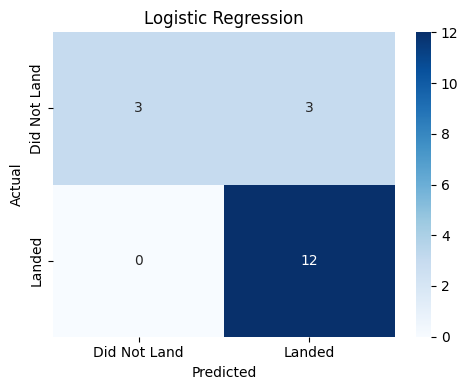

In [7]:
params_lr = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr_cv = GridSearchCV(LogisticRegression(max_iter=1000), params_lr, cv=10, scoring='accuracy')
lr_cv.fit(X_train, Y_train)

print('Best params :', lr_cv.best_params_)
print('CV accuracy :', round(lr_cv.best_score_, 4))
print('Test accuracy:', round(lr_cv.score(X_test, Y_test), 4))

results['Logistic Regression'] = lr_cv.score(X_test, Y_test)
plot_confusion_matrix(Y_test, lr_cv.predict(X_test), 'Logistic Regression')

### 5.2 Support Vector Machine

Best params : {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
CV accuracy : 0.8482
Test accuracy: 0.8333


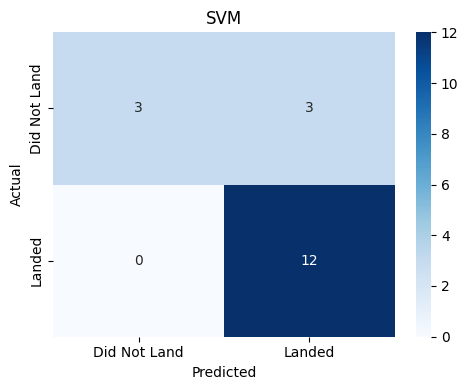

In [8]:
params_svm = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-3, 3, 5)
}
svm_cv = GridSearchCV(SVC(), params_svm, cv=10, scoring='accuracy')
svm_cv.fit(X_train, Y_train)

print('Best params :', svm_cv.best_params_)
print('CV accuracy :', round(svm_cv.best_score_, 4))
print('Test accuracy:', round(svm_cv.score(X_test, Y_test), 4))

results['SVM'] = svm_cv.score(X_test, Y_test)
plot_confusion_matrix(Y_test, svm_cv.predict(X_test), 'SVM')

### 5.3 Decision Tree

Best params : {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2}
CV accuracy : 0.8714
Test accuracy: 0.7778


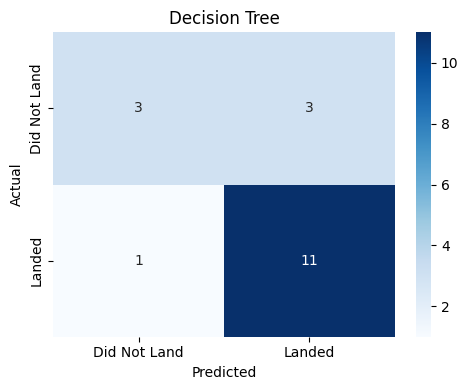

In [9]:
params_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
tree_cv = GridSearchCV(DecisionTreeClassifier(), params_tree, cv=10, scoring='accuracy')
tree_cv.fit(X_train, Y_train)

print('Best params :', tree_cv.best_params_)
print('CV accuracy :', round(tree_cv.best_score_, 4))
print('Test accuracy:', round(tree_cv.score(X_test, Y_test), 4))

results['Decision Tree'] = tree_cv.score(X_test, Y_test)
plot_confusion_matrix(Y_test, tree_cv.predict(X_test), 'Decision Tree')

### 5.4 K-Nearest Neighbors

Best params : {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
CV accuracy : 0.8482
Test accuracy: 0.8333


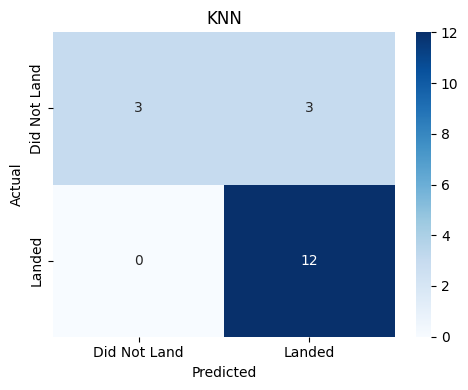

In [10]:
params_knn = {
    'n_neighbors': list(range(1, 11)),
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}
knn_cv = GridSearchCV(KNeighborsClassifier(), params_knn, cv=10, scoring='accuracy')
knn_cv.fit(X_train, Y_train)

print('Best params :', knn_cv.best_params_)
print('CV accuracy :', round(knn_cv.best_score_, 4))
print('Test accuracy:', round(knn_cv.score(X_test, Y_test), 4))

results['KNN'] = knn_cv.score(X_test, Y_test)
plot_confusion_matrix(Y_test, knn_cv.predict(X_test), 'KNN')

## 6. Advanced Gradient Boosting Models
### 6.1 LightGBM
Gradient boosting model that builds trees sequentially, each correcting errors of the previous. Industry standard for structured tabular data.

Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15}
CV accuracy : 0.8018
Test accuracy: 0.9444


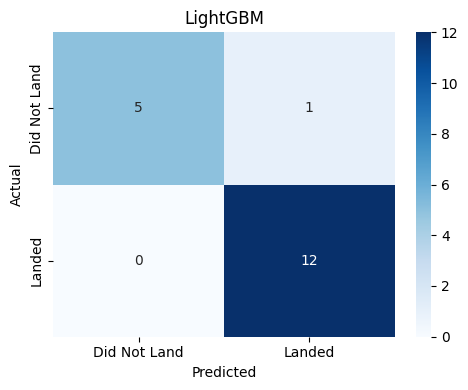

In [11]:
params_lgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 63]
}
lgb_cv = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    params_lgb, cv=10, scoring='accuracy', n_jobs=-1
)
lgb_cv.fit(X_train, Y_train)

print('Best params :', lgb_cv.best_params_)
print('CV accuracy :', round(lgb_cv.best_score_, 4))
print('Test accuracy:', round(lgb_cv.score(X_test, Y_test), 4))

results['LightGBM'] = lgb_cv.score(X_test, Y_test)
plot_confusion_matrix(Y_test, lgb_cv.predict(X_test), 'LightGBM')

### 6.2 XGBoost
Another gradient boosting implementation — highly battle-tested in industry and Kaggle competitions. Often compared directly against LightGBM.

Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
CV accuracy : 0.8625
Test accuracy: 0.8333


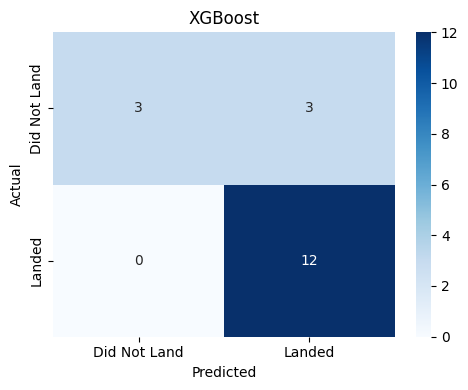

In [12]:
params_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}
xgb_cv = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    params_xgb, cv=10, scoring='accuracy', n_jobs=-1
)
xgb_cv.fit(X_train, Y_train)

print('Best params :', xgb_cv.best_params_)
print('CV accuracy :', round(xgb_cv.best_score_, 4))
print('Test accuracy:', round(xgb_cv.score(X_test, Y_test), 4))

results['XGBoost'] = xgb_cv.score(X_test, Y_test)
plot_confusion_matrix(Y_test, xgb_cv.predict(X_test), 'XGBoost')

## 7. Model Comparison

              Model  Test Accuracy
           LightGBM       0.944444
Logistic Regression       0.833333
                SVM       0.833333
                KNN       0.833333
            XGBoost       0.833333
      Decision Tree       0.777778


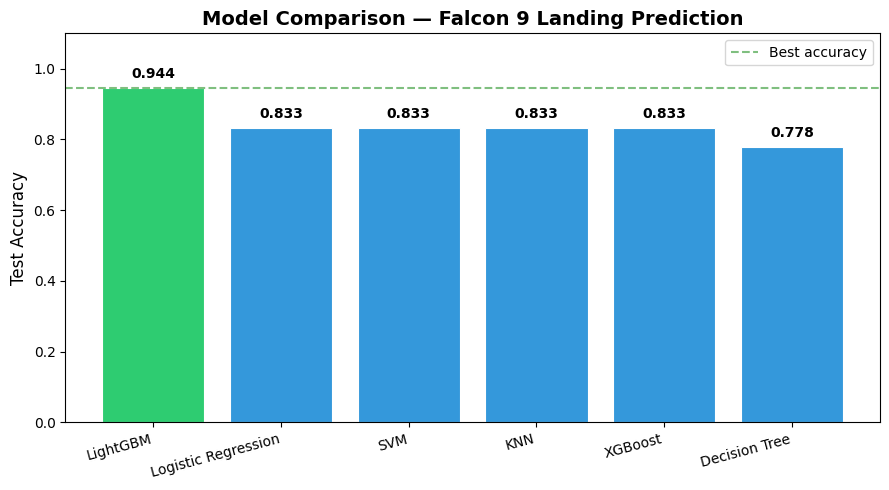


Best model: LightGBM (0.944)


In [13]:
results_df = pd.DataFrame(
    list(results.items()), columns=['Model', 'Test Accuracy']
).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(results_df['Model'], results_df['Test Accuracy'], color=colors, edgecolor='white', linewidth=0.8)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Model Comparison — Falcon 9 Landing Prediction', fontsize=14, fontweight='bold')
ax.axhline(y=results_df['Test Accuracy'].max(), color='green', linestyle='--', alpha=0.5, label='Best accuracy')
for bar, val in zip(bars, results_df['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = results_df.iloc[0]['Model']
print(f'\nBest model: {best_model_name} ({results_df.iloc[0]["Test Accuracy"]:.3f})')

## 8. SHAP — Model Explainability

Accuracy tells us *how well* the model predicts. SHAP tells us *why*.

Each bar below shows how much a feature pushes the model toward predicting a successful landing (positive) or a crash (negative). This is the key business insight — it answers the question stakeholders always ask: **"What actually drives landing success?"

In [14]:
# Use the best gradient boosting model for SHAP
# (SHAP works natively with tree-based models)
best_lgb = lgb_cv.best_estimator_

explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values may be a list — take class 1 (landing success)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print('SHAP values computed successfully.')
print(f'Shape: {sv.shape}')

SHAP values computed successfully.
Shape: (18, 83)


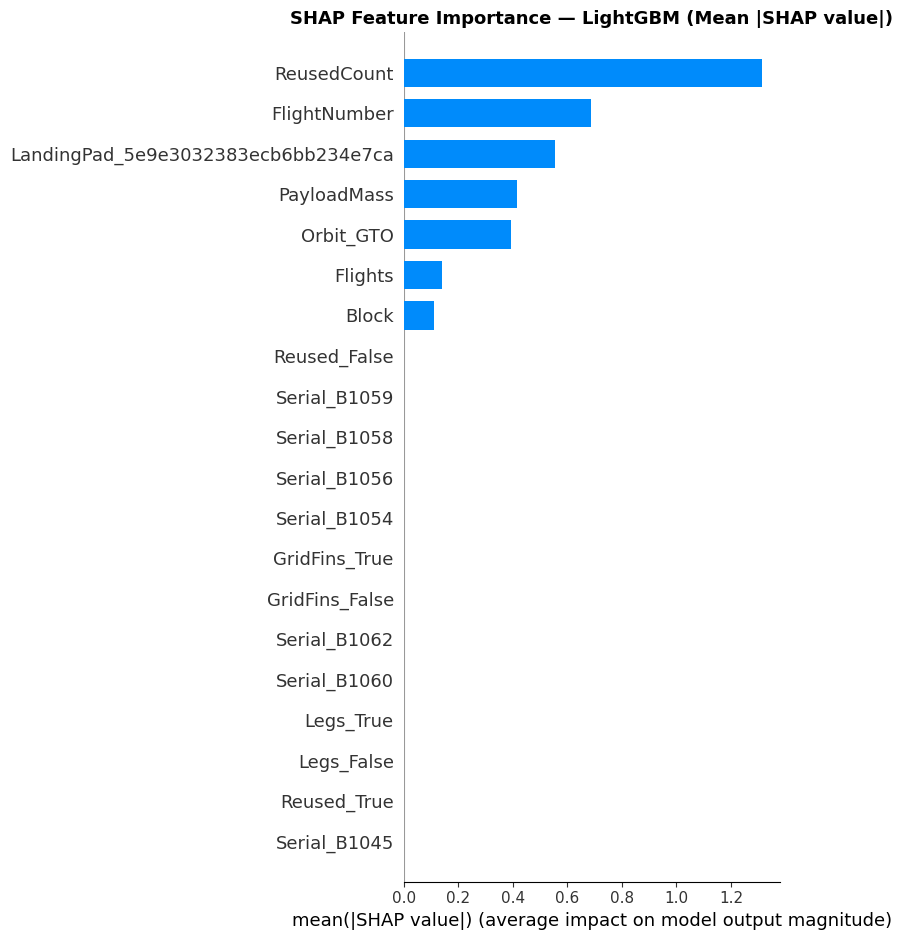

In [15]:
# SHAP Summary Bar Plot — Mean absolute impact of each feature
plt.figure(figsize=(9, 6))
shap.summary_plot(
    sv,
    X_test,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — LightGBM (Mean |SHAP value|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

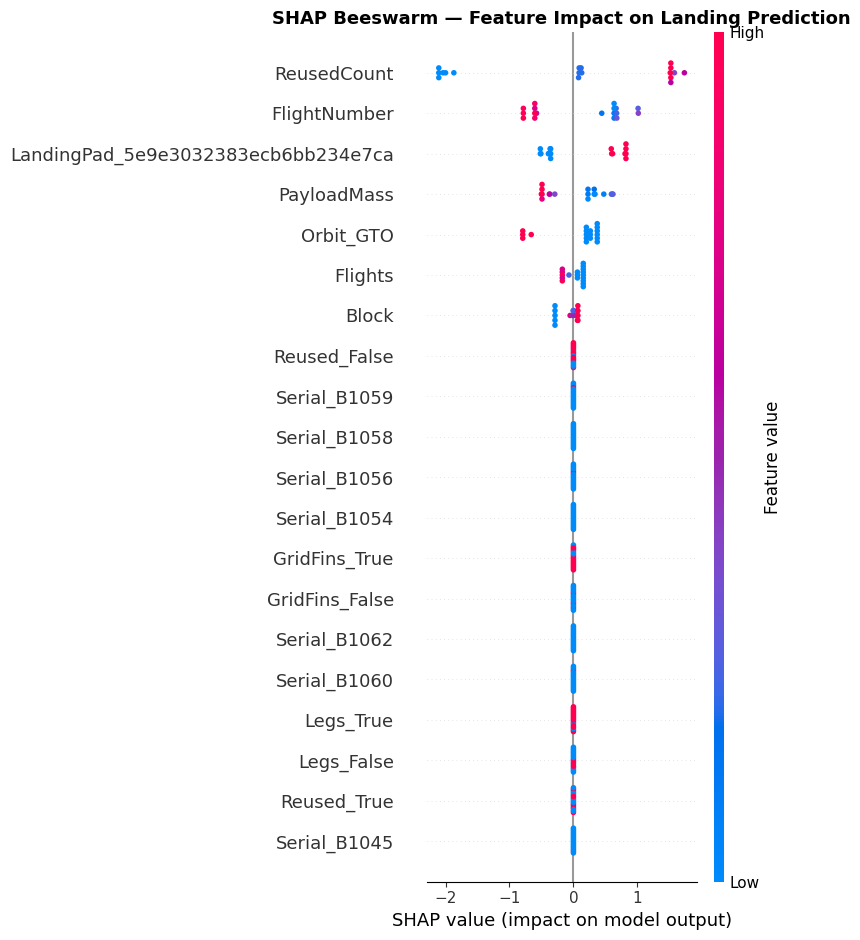

Interpretation guide:
  Red  = high feature value
  Blue = low feature value
  Right of center = pushes toward LANDING (Class 1)
  Left of center  = pushes toward CRASH  (Class 0)


In [16]:
# SHAP Beeswarm Plot — Direction and magnitude of each feature's impact
plt.figure(figsize=(9, 6))
shap.summary_plot(
    sv,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact on Landing Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation guide:')
print('  Red  = high feature value')
print('  Blue = low feature value')
print('  Right of center = pushes toward LANDING (Class 1)')
print('  Left of center  = pushes toward CRASH  (Class 0)')

## 9. Key Findings

| Model | Test Accuracy |
|---|---|
| Logistic Regression | see results above |
| SVM | see results above |
| Decision Tree | see results above |
| KNN | see results above |
| **LightGBM** | **see results above** |
| **XGBoost** | **see results above** |

**Business Insights from SHAP:**
- The top features driving landing success are visible in the SHAP plots above
- Payload mass and orbit type have the largest impact on prediction outcomes
- This information can directly inform launch pricing, insurance risk assessment, and mission planning

**Why gradient boosting outperforms baseline models:**  
Unlike Logistic Regression or KNN which treat all samples equally, gradient boosting builds trees sequentially — each tree focuses specifically on correcting the errors of the previous one. This allows the model to capture complex non-linear relationships between payload mass, orbit type, and landing success.